In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import dataset and do initial exploratiion
df = pd.read_csv(r"C:\Users\joaqu\Downloads\heart_disease_uci.csv")
if "id" in df.columns:
    df = df.drop(columns=["id"])

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(920, 15)

First 5 Rows:
   age     sex    dataset               cp  trestbps   chol    fbs  \
0   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal

In [14]:
# drop missing values before modeling
df = df.dropna()

print("Dataset shape after dropping NaN values:", df.shape)

Dataset shape after dropping NaN values: (299, 16)


In [15]:
# 3. Create binary target
# Original column: num
# 0 = no heart disease
# 1,2,3,4 = heart disease present

df["heart_disease"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

print("\nTarget Distribution:")
print(df["heart_disease"].value_counts())

print("\nTarget Distribution Percentage:")
print(df["heart_disease"].value_counts(normalize=True) * 100)


Target Distribution:
heart_disease
0    160
1    139
Name: count, dtype: int64

Target Distribution Percentage:
heart_disease
0    53.511706
1    46.488294
Name: proportion, dtype: float64


In [16]:
# 4. Separate column types

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)


# 5. Summary statistics

print("\nSummary Statistics:")
print(df.describe())

print("\nCategorical Summary:")
print(df.describe(include=["object", "bool"]))


Numerical Columns:
Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num',
       'heart_disease'],
      dtype='object')

Categorical Columns:
Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')

Summary Statistics:
              age    trestbps        chol      thalch     oldpeak          ca  \
count  299.000000  299.000000  299.000000  299.000000  299.000000  299.000000   
mean    54.521739  131.715719  246.785953  149.327759    1.058528    0.672241   
std      9.030264   17.747751   52.532582   23.121062    1.162769    0.937438   
min     29.000000   94.000000  100.000000   71.000000    0.000000    0.000000   
25%     48.000000  120.000000  211.000000  132.500000    0.000000    0.000000   
50%     56.000000  130.000000  242.000000  152.000000    0.800000    0.000000   
75%     61.000000  140.000000  275.500000  165.500000    1.600000    1.000000   
max     77.000000  200.000000  564.000000  202.000000    6.200000    3.000000   



In [17]:
TARGET_COL = 'heart_disease'

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print(f'Features : {X.shape[1]} columns')
print(f'Samples  : {X.shape[0]}')
print(f'Target   : {y.name}  |  unique values: {sorted(y.unique())}')

Features : 15 columns
Samples  : 299
Target   : heart_disease  |  unique values: [np.int64(0), np.int64(1)]


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves class balance in both splits
)

print(f'Train size : {X_train.shape[0]} rows')
print(f'Test size  : {X_test.shape[0]} rows')

Train size : 239 rows
Test size  : 60 rows


In [19]:
# 1. Create binary target variable
# In this dataset:
# num = 0 means no heart disease
# num = 1, 2, 3, or 4 means heart disease is present

df["heart_disease"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

# 2. Split features and target

X = df.drop(columns=["num", "heart_disease"])
y = df["heart_disease"]

# Drop id column if it exists because it is only an identifier
if "id" in X.columns:
    X = X.drop(columns=["id"])

In [20]:
# 3. Identify numerical and categorical columns

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns

print("Numerical columns:")
print(list(numerical_cols))

print("\nCategorical columns:")
print(list(categorical_cols))

Numerical columns:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Categorical columns:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [21]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 4. Preprocessing
# KNN needs numbers only.
# Numerical columns are scaled.
# Categorical columns are one-hot encoded.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        LogisticRegression(random_state=42))  # default params — no tuning yet
])

pipeline.fit(X_train, y_train)

lr = pipeline.named_steps['model']
print('Pipeline trained.')
print(f'Solver     : {lr.solver}')
print(f'Iterations : {lr.n_iter_[0]}')
print(f'Classes    : {lr.classes_}')

Pipeline trained.
Solver     : lbfgs
Iterations : 28
Classes    : [0 1]


In [23]:
# Pass raw X_test — the pipeline handles preprocessing internally
y_pred      = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)[:, 1]  # probability for the positive class

# Quick peek at predictions
pred_df = pd.DataFrame({
    'actual'     : y_test.values,
    'predicted'  : y_pred,
    'prob_class1': y_pred_prob.round(3)
})
pred_df.head(10)

,actual,predicted,prob_class1
0,0,0,0.029
1,0,0,0.047
2,0,0,0.500
3,0,0,0.240
4,0,0,0.450
5,0,0,0.011
6,1,1,0.904
7,0,0,0.061
8,1,0,0.330
9,0,0,0.057


In [24]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy : {acc:.4f}')
print(f'ROC-AUC  : {auc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy : 0.8500
ROC-AUC  : 0.9308

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        32
           1       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



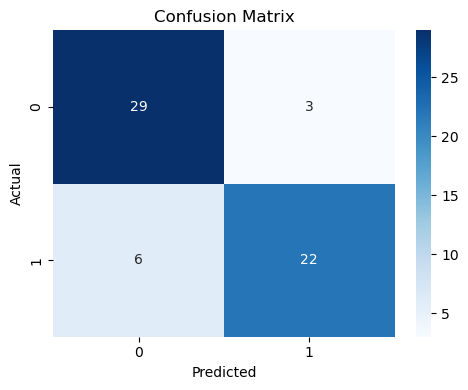

In [25]:
# generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lr.classes_,
    yticklabels=lr.classes_,
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [26]:
# interpretation
# Recover feature names after OHE expansion
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

coef_df = pd.DataFrame({
    'feature'    : feature_names,
    'coefficient': lr.coef_[0],
    'odds_ratio' : np.exp(lr.coef_[0])  # exp(coef) = multiplicative change in odds per unit
}).sort_values('coefficient', key=abs, ascending=False)

print('Feature importance (by absolute coefficient):')
coef_df

Feature importance (by absolute coefficient):


,feature,coefficient,odds_ratio
10,cat__cp_asymptomatic,1.036730,2.819980
26,cat__thal_reversable defect,1.005692,2.733799
5,num__ca,0.913685,2.493494
12,cat__cp_non-anginal,-0.685459,0.503859
13,cat__cp_typical angina,-0.653501,0.520221
25,cat__thal_normal,-0.621902,0.536922
6,cat__sex_Female,-0.611059,0.542776
7,cat__sex_Male,0.610982,1.842240
23,cat__slope_upsloping,-0.490094,0.612569
4,num__oldpeak,0.484487,1.623341


Now optimize parameters for better results

In [27]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        LogisticRegression(random_state=42))
])

baseline_pipeline.fit(X_train, y_train)

y_pred_base      = baseline_pipeline.predict(X_test)
y_pred_prob_base = baseline_pipeline.predict_proba(X_test)[:, 1]

baseline_acc = accuracy_score(y_test, y_pred_base)
baseline_auc = roc_auc_score(y_test, y_pred_prob_base)

print(f'Baseline  Accuracy : {baseline_acc:.4f}')
print(f'Baseline  ROC-AUC  : {baseline_auc:.4f}')

Baseline  Accuracy : 0.8500
Baseline  ROC-AUC  : 0.9308


In [28]:
from sklearn.model_selection import GridSearchCV

# Pipeline keys follow the pattern  <step_name>__<param_name>
param_grid = {
    'model__C'            : [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty'      : ['l1', 'l2'],
    'model__solver'       : ['liblinear'],   # supports both l1 and l2
    'model__class_weight' : [None, 'balanced']
}

tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        LogisticRegression(random_state=42, max_iter=1000))
])

grid_search = GridSearchCV(
    estimator  = tuning_pipeline,
    param_grid = param_grid,
    cv         = 5,                # 5-fold stratified CV
    scoring    = 'roc_auc',        # optimise for AUC; change to 'f1' or 'accuracy' if preferred
    n_jobs     = -1,               # use all available CPU cores
    verbose    = 1,
    refit      = True              # refit best params on full X_train after search
)

grid_search.fit(X_train, y_train)

print('\nBest parameters found:')
for param, value in grid_search.best_params_.items():
    print(f'  {param:<30} : {value}')
print(f'\nBest cross-val ROC-AUC : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters found:
  model__C                       : 0.1
  model__class_weight            : None
  model__penalty                 : l2
  model__solver                  : liblinear

Best cross-val ROC-AUC : 0.9014


In [29]:
# Inspect full CV results as a sorted DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)
cols = ['param_model__C', 'param_model__penalty',
        'param_model__class_weight',
        'mean_test_score', 'std_test_score', 'rank_test_score']
cv_results[cols].sort_values('rank_test_score').head(10)

,param_model__C,param_model__penalty,param_model__class_weight,mean_test_score,std_test_score,rank_test_score
9,0.10,l2,None,0.901385,0.044929,1
11,0.10,l2,balanced,0.901357,0.046032,2
13,1.00,l2,None,0.896045,0.043295,3
15,1.00,l2,balanced,0.894255,0.043791,4
7,0.01,l2,balanced,0.893860,0.045219,5
5,0.01,l2,None,0.893528,0.045409,6
12,1.00,l1,None,0.892147,0.044611,7
14,1.00,l1,balanced,0.890722,0.044853,8
8,0.10,l1,None,0.887365,0.031536,9
16,10.00,l1,None,0.887206,0.044515,10


In [30]:
best_pipeline = grid_search.best_estimator_

y_pred      = best_pipeline.predict(X_test)
y_pred_prob = best_pipeline.predict_proba(X_test)[:, 1]

pred_df = pd.DataFrame({
    'actual'     : y_test.values,
    'predicted'  : y_pred,
    'prob_class1': y_pred_prob.round(3)
})
pred_df.head(10)

,actual,predicted,prob_class1
0,0,0,0.060
1,0,0,0.105
2,0,0,0.419
3,0,0,0.277
4,0,0,0.427
5,0,0,0.047
6,1,1,0.839
7,0,0,0.105
8,1,0,0.372
9,0,0,0.119


In [31]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

tuned_acc = accuracy_score(y_test, y_pred)
tuned_auc = roc_auc_score(y_test, y_pred_prob)

comparison = pd.DataFrame({
    'Metric'   : ['Accuracy', 'ROC-AUC'],
    'Baseline' : [round(baseline_acc, 4), round(baseline_auc, 4)],
    'Tuned'    : [round(tuned_acc, 4),    round(tuned_auc, 4)],
})
comparison['Delta'] = (comparison['Tuned'] - comparison['Baseline']).round(4)
print(comparison.to_string(index=False))

print('\nClassification Report (tuned model):')
print(classification_report(y_test, y_pred))

  Metric  Baseline  Tuned  Delta
Accuracy    0.8500  0.850 0.0000
 ROC-AUC    0.9308  0.942 0.0112

Classification Report (tuned model):
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        32
           1       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60

